In [1]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [2]:
COLUMN_NAMES = [
    "age",
    "workclass",
    "fnlwgt",          # "final weight" - a census sampling weight, explained in README
    "education",
    "education_num",   # numeric version of the education column
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income",           # this is our TARGET column: <=50K or >50K
]

In [3]:
RAW_TRAIN_PATH = "../data/raw/adult_train.data"
RAW_TEST_PATH = "../data/raw/adult_test.test"
OUTPUT_PATH = "adult_combined.csv"


In [4]:
train_df = pd.read_csv(
        RAW_TRAIN_PATH,
        header=None,           # the raw file has no column names, we supply our own (from readme file)
        names=COLUMN_NAMES,
        sep=",",
        skipinitialspace=True,  # removes the leading space before every value
        na_values="?",           # tell pandas that "?" means missing data
    )
print(f"  -> {train_df.shape[0]} rows, {train_df.shape[1]} columns")
train_df.head()


  -> 32561 rows, 15 columns


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
test_df = pd.read_csv(
        RAW_TEST_PATH,
        header=None,
        names=COLUMN_NAMES,
        sep=",",
        skipinitialspace=True,
        na_values="?",
        skiprows=1,   # skip the 1st line :"1x3 Cross validator" junk line
    )
    # In this file, income values look like "<=50K." with a trailing full stop.
    # We strip that dot off so it matches the train file exactly.
test_df["income"] = test_df["income"].str.replace(".", "", regex=False)
print(f"  -> {test_df.shape[0]} rows, {test_df.shape[1]} columns")
test_df.head()

  -> 16281 rows, 15 columns


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [6]:
#Combining both files into one dataset (ignoring UCI's original split)
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print(f"  -> Combined shape: {combined_df.shape}")

  -> Combined shape: (48842, 15)


In [7]:
#Checking missing values (marked as '?' in the raw files) per column
missing_counts = combined_df.isnull().sum()
print(missing_counts[missing_counts > 0])

workclass         2799
occupation        2809
native_country     857
dtype: int64


In [8]:
#Removing exact duplicate rows
before = combined_df.shape[0]
combined_df = combined_df.drop_duplicates().reset_index(drop=True)
after = combined_df.shape[0]
print(f"  -> Removed {before - after} duplicate rows. New shape: {combined_df.shape}")

  -> Removed 52 duplicate rows. New shape: (48790, 15)


In [9]:
#Checking class balance of the 'income' column 
print(combined_df["income"].value_counts())
print(combined_df["income"].value_counts(normalize=True).round(4) * 100)


income
<=50K    37109
>50K     11681
Name: count, dtype: int64
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64


In [10]:
combined_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved cleaned & combined dataset to: {OUTPUT_PATH}")


Saved cleaned & combined dataset to: adult_combined.csv


## EDA

In [11]:
NUMERIC_COLS = ["age", "fnlwgt", "education_num", "capital_gain",
                 "capital_loss", "hours_per_week"]
CATEGORICAL_COLS = ["workclass", "education", "marital_status", "occupation",
                     "relationship", "race", "sex", "native_country"]


In [12]:
DATA_PATH = "adult_combined.csv"


In [13]:
df = pd.read_csv(DATA_PATH)

In [14]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Missing values per column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Rows: 48790, Columns: 15
Missing values per column:
workclass         2795
occupation        2805
native_country     856
dtype: int64


In [15]:
#income class distribution
counts = df["income"].value_counts()
pct = df["income"].value_counts(normalize=True) * 100
print(f"{counts}\n\nPercentages:\n{pct.round(2)}")

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

Percentages:
income
<=50K    76.06
>50K     23.94
Name: proportion, dtype: float64


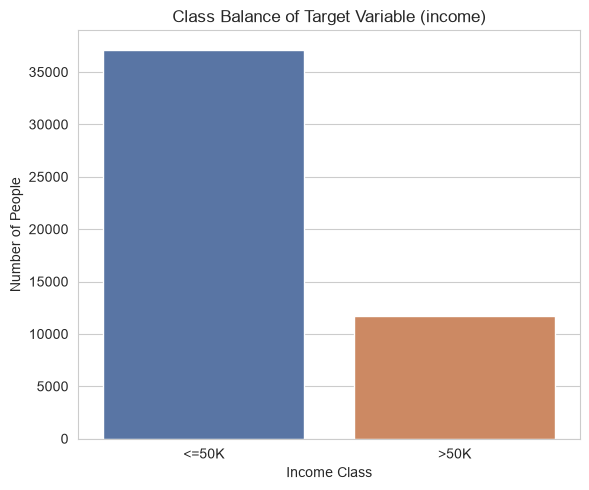

In [16]:
#plotting "income" class distribution (binary class distribution)
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="income",hue="income", palette=["#4C72B0", "#DD8452"])
plt.title("Class Balance of Target Variable (income)")
plt.xlabel("Income Class")
plt.ylabel("Number of People")
plt.tight_layout()
plt.savefig(f"01_target_class_balance.png", dpi=120)


age                0.557
fnlwgt             1.440
education_num     -0.314
capital_gain      11.888
capital_loss       4.567
hours_per_week     0.240
dtype: float64


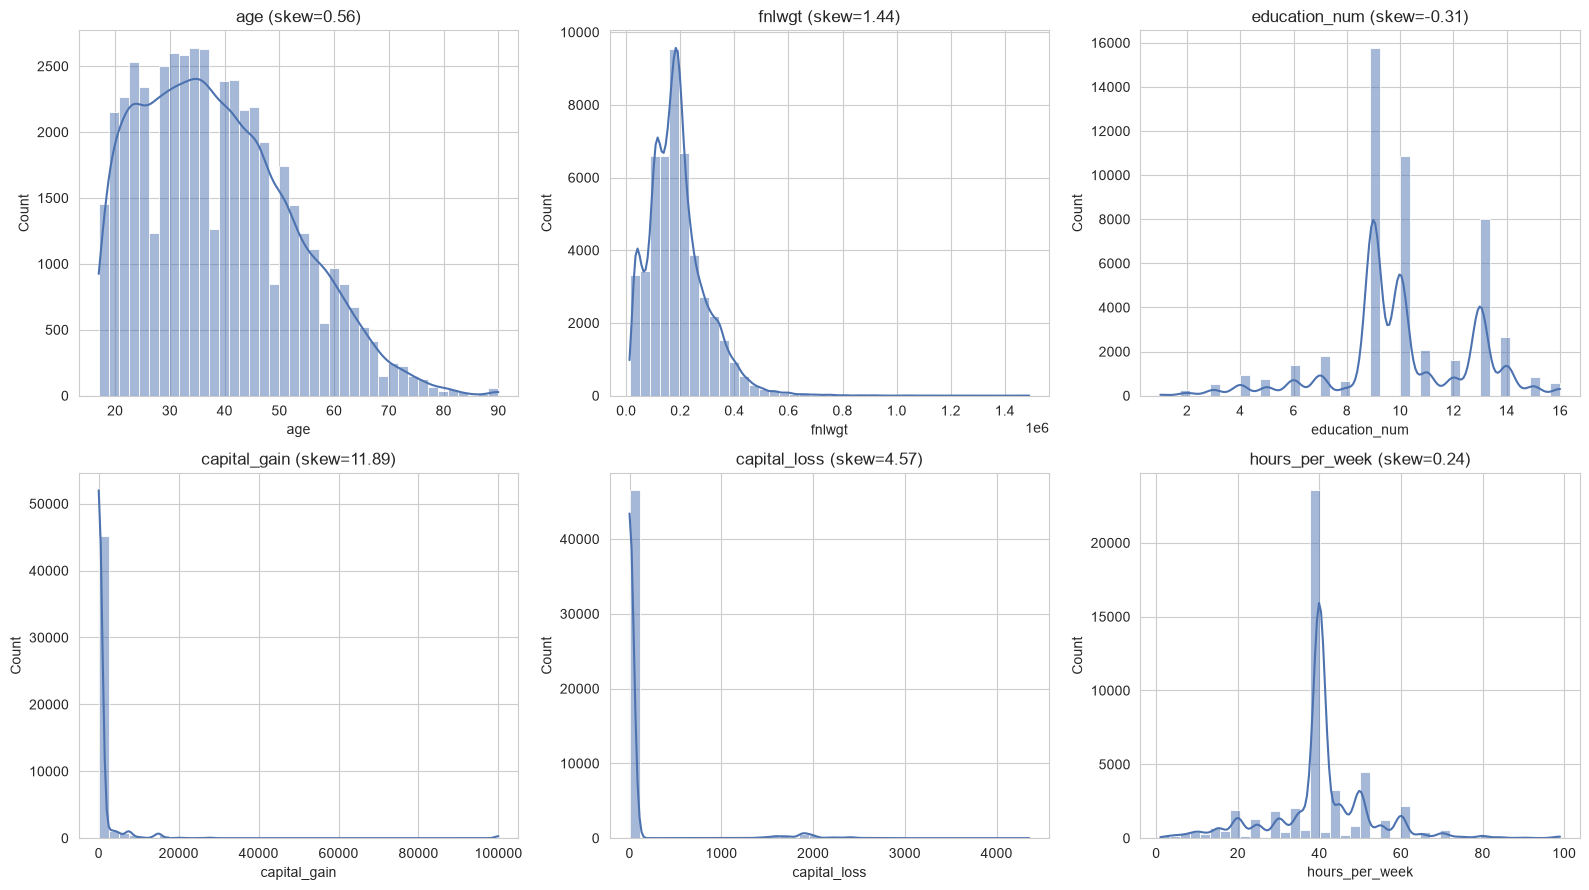

In [17]:
#skewness in numerical variables

skew_values = df[NUMERIC_COLS].skew()
print(skew_values.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), NUMERIC_COLS):
    sns.histplot(df[col], bins=40, ax=ax, kde=True, color="#4C72B0")
    ax.set_title(f"{col} (skew={df[col].skew():.2f})")
plt.tight_layout()
plt.savefig(f"02_numeric_distributions.png", dpi=120)



In [18]:
#proportion of 0's in capital gain/ capital loss
zero_gain_pct = (df["capital_gain"] == 0).mean() * 100
zero_loss_pct = (df["capital_loss"] == 0).mean() * 100

print(f"Percentage of rows where capital_gain == 0: {zero_gain_pct:.2f}%")
print(f"Percentage of rows where capital_loss == 0: {zero_loss_pct:.2f}%")

Percentage of rows where capital_gain == 0: 91.73%
Percentage of rows where capital_loss == 0: 95.32%


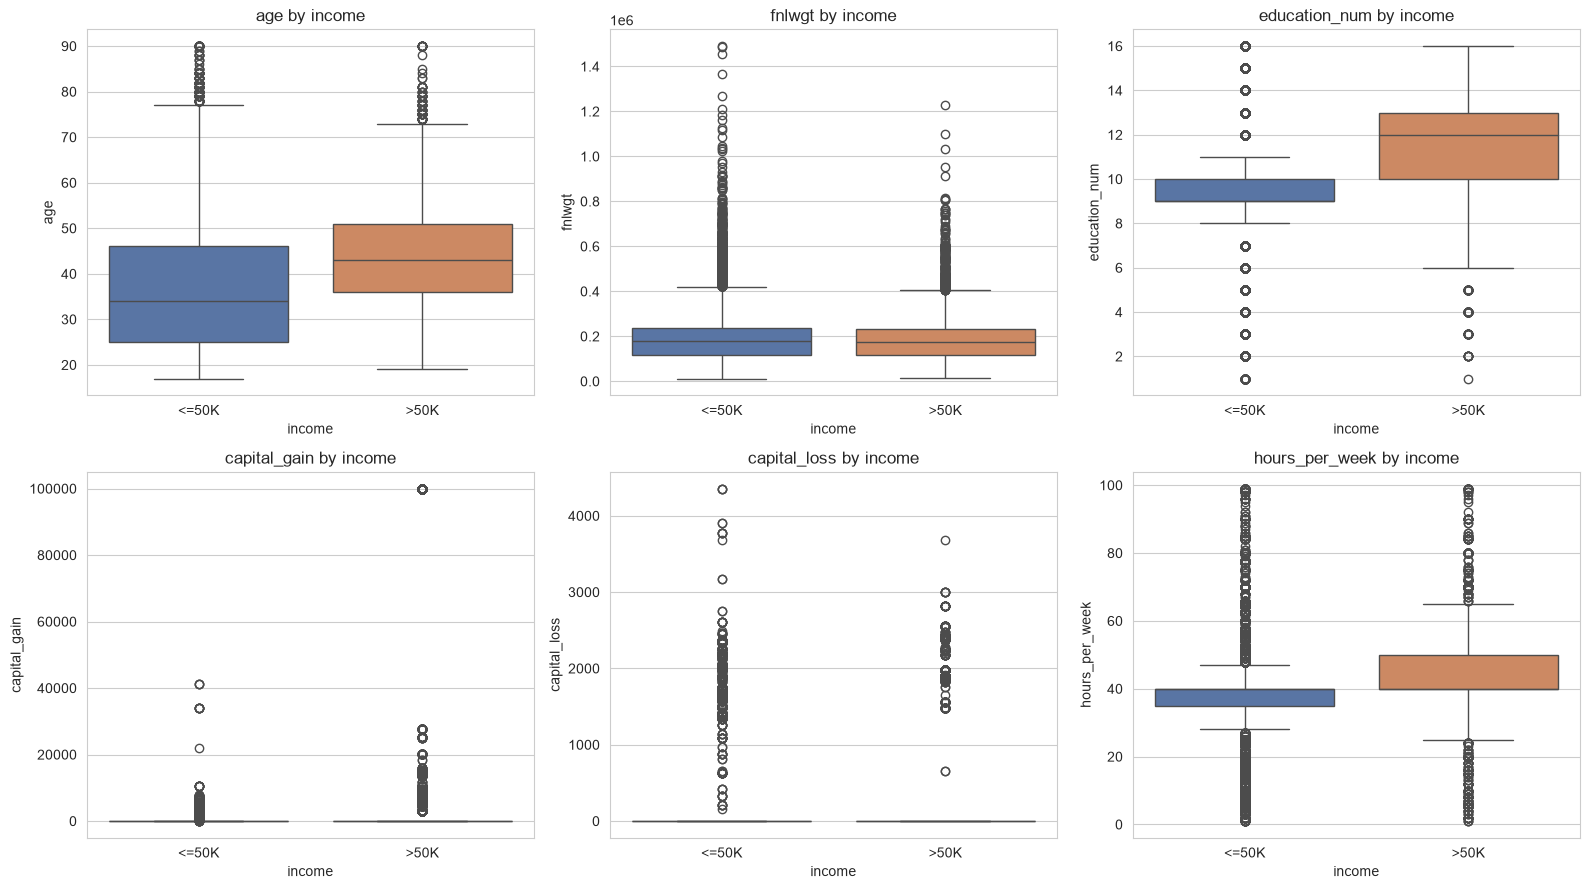

In [19]:
# numerical features vs income box-plot with wiskers
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), NUMERIC_COLS):
    sns.boxplot(data=df, x="income", hue="income",y=col, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"{col} by income")
plt.tight_layout()
plt.savefig(f"03_numeric_boxplots_by_income.png", dpi=120)


                  age  fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000  -0.076          0.031         0.077         0.057   
fnlwgt         -0.076   1.000         -0.039        -0.004        -0.004   
education_num   0.031  -0.039          1.000         0.125         0.081   
capital_gain    0.077  -0.004          0.125         1.000        -0.031   
capital_loss    0.057  -0.004          0.081        -0.031         1.000   
hours_per_week  0.071  -0.014          0.144         0.082         0.054   

                hours_per_week  
age                      0.071  
fnlwgt                  -0.014  
education_num            0.144  
capital_gain             0.082  
capital_loss             0.054  
hours_per_week           1.000  


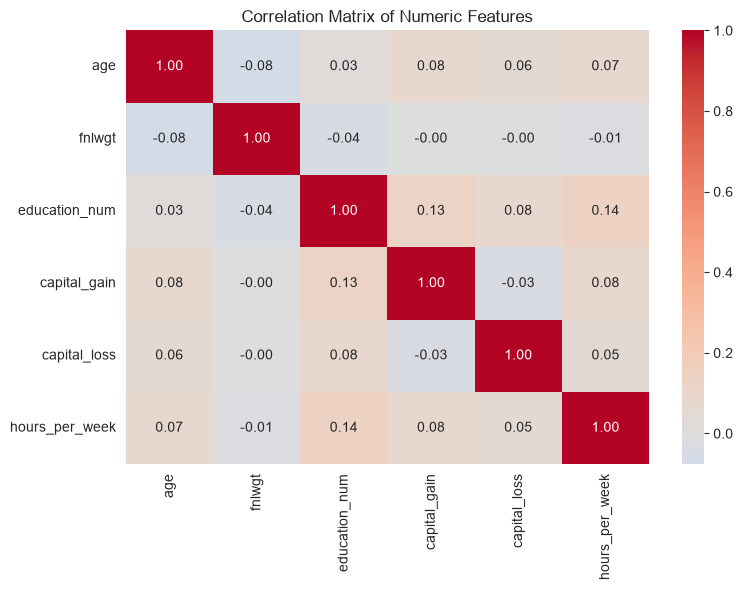

In [20]:
#corelation matrix btween neumerical features
corr = df[NUMERIC_COLS].corr()
print(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.savefig(f"04_correlation_heatmap.png", dpi=120)



In [21]:
# CARDINALITY OF CATEGORICAL COLUMNS (unique value counts)")
for col in CATEGORICAL_COLS:
    print(f"{col}: {df[col].nunique()} unique values")

workclass: 8 unique values
education: 16 unique values
marital_status: 7 unique values
occupation: 14 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native_country: 41 unique values


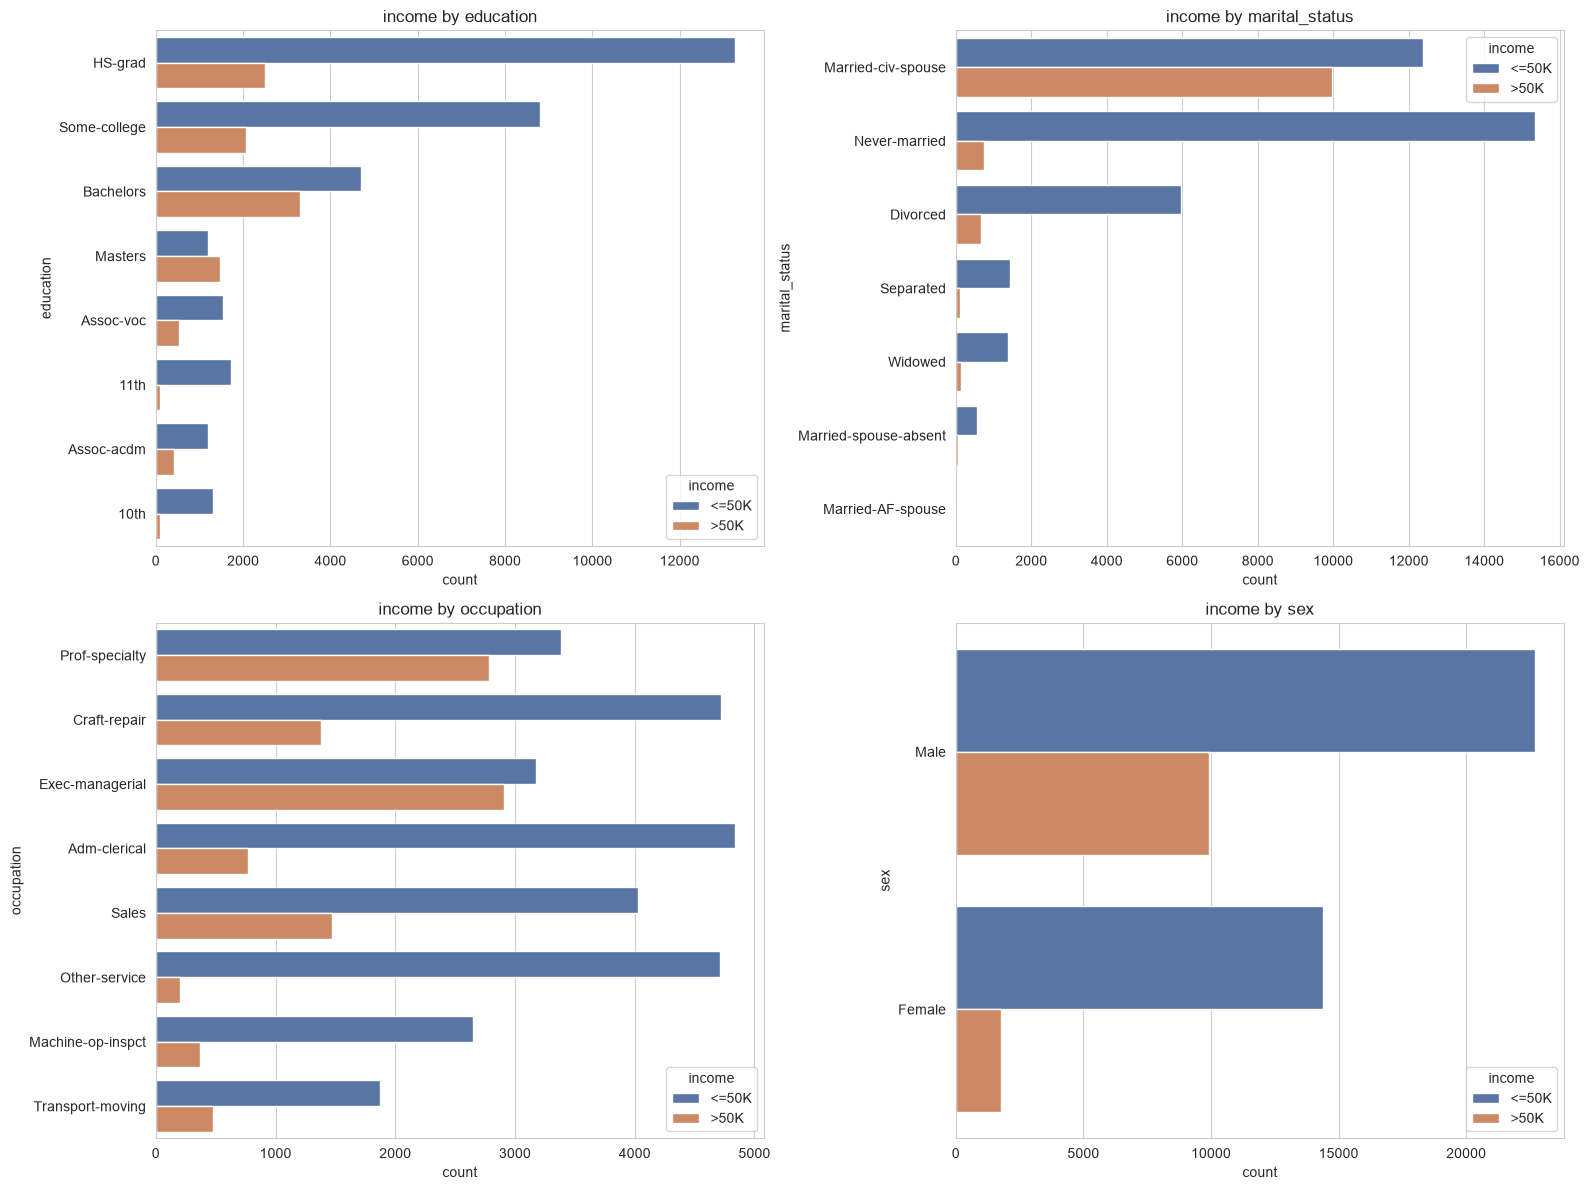

In [22]:
#categorical features(those intuitively have relation with income) and income distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
important_cats = ["education", "marital_status", "occupation", "sex"]
for ax, col in zip(axes.flatten(), important_cats):
    top_categories = df[col].value_counts().nlargest(8).index
    subset = df[df[col].isin(top_categories)]
    sns.countplot(data=subset, y=col, hue="income", ax=ax,
                    order=top_categories, palette=["#4C72B0", "#DD8452"])
    ax.set_title(f"income by {col}")
plt.tight_layout()
plt.savefig(f"05_categorical_vs_income.png", dpi=120)



In [23]:
#checking if education and education_num are related, if every education implies +1 in education_num
redundancy_check = df.groupby("education")["education_num"].nunique()
is_redundant = (redundancy_check == 1).all()